**Setup & Import**

In [1]:
# ── Import semua library yang dibutuhkan ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter

# ── Warna konsisten untuk semua grafik ───────────────────────────────────────
WARNA_1  = "#2E86AB"   # biru utama
WARNA_2  = "#E84855"   # merah aksen
WARNA_3  = "#3BB273"   # hijau positif
WARNA_4  = "#F7B731"   # kuning/oranye
WARNA_BG = "#F8F9FA"   # background panel

# ── Konfigurasi tampilan global ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": WARNA_BG,
    "axes.facecolor"  : WARNA_BG,
    "axes.titlesize"  : 14,
    "axes.labelsize"  : 12,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
    "legend.fontsize" : 10,
})
sns.set_theme(style="whitegrid", palette="viridis")

print("✅ Setup selesai!")

✅ Setup selesai!


**Perumusan Masalah Bisnis (PB 1–7)**

In [2]:
# ── Dokumentasi 7 Pertanyaan Bisnis ──────────────────────────────────────────
pertanyaan_bisnis = [
    {
        "Kode"    : "PB-1",
        "Pertanyaan" : "Produk apa yang paling sering dipesan pelanggan?",
        "Metrik"  : "Frekuensi kemunculan nama produk di kolom 'product'",
        "Manfaat" : "Pemilik tahu produk prioritas yang harus selalu tersedia",
        "Dataset" : "chatkasir_synthetic.csv"
    },
    {
        "Kode"    : "PB-2",
        "Pertanyaan" : "Berapa rata-rata nilai transaksi (harga satuan) per pesanan?",
        "Metrik"  : "Mean, median, dan distribusi kolom 'price_satuan'",
        "Manfaat" : "Dasar penentuan harga dan estimasi pendapatan harian",
        "Dataset" : "chatkasir_synthetic.csv"
    },
    {
        "Kode"    : "PB-3",
        "Pertanyaan" : "Bagaimana distribusi rentang harga produk yang dijual?",
        "Metrik"  : "Segmentasi harga: Murah / Sedang / Agak Mahal / Mahal",
        "Manfaat" : "Memahami segmen harga yang mendominasi menu",
        "Dataset" : "chatkasir_synthetic.csv"
    },
    {
        "Kode"    : "PB-4",
        "Pertanyaan" : "Pola kalimat pesanan mana yang paling sering digunakan?",
        "Metrik"  : "Distribusi kolom 'pattern' (pola 1–4)",
        "Manfaat" : "Prioritas pengembangan model NLP untuk pola paling umum",
        "Dataset" : "chatkasir_synthetic.csv"
    },
    {
        "Kode"    : "PB-5",
        "Pertanyaan" : "Kata slang apa yang paling sering muncul dalam percakapan?",
        "Metrik"  : "Frekuensi kemunculan kata slang di teks obrolan",
        "Manfaat" : "Menentukan kata prioritas untuk kamus normalisasi teks AI",
        "Dataset" : "slang_utama.csv + chatkasir_synthetic.csv"
    },
    {
        "Kode"    : "PB-6",
        "Pertanyaan" : "Berapa porsi pesanan yang tidak menyebut harga secara eksplisit?",
        "Metrik"  : "Persentase baris dengan price_satuan == -1",
        "Manfaat" : "Mengukur seberapa sering model harus tangani kasus tanpa harga",
        "Dataset" : "chatkasir_synthetic.csv"
    },
    {
        "Kode"    : "PB-7",
        "Pertanyaan" : "Bagaimana distribusi jenis kuantitas pesanan (angka vs teks)?",
        "Metrik"  : "Proporsi qty numerik vs deskriptif (setengah, seporsi, dll.)",
        "Manfaat" : "Merancang parser kuantitas yang menangani teks sekaligus angka",
        "Dataset" : "chatkasir_synthetic.csv"
    },
]

# ── Tampilkan sebagai tabel ───────────────────────────────────────────────────
df_pb = pd.DataFrame(pertanyaan_bisnis)
print("=" * 75)
print("  DAFTAR PERTANYAAN BISNIS — ChatKasir Dashboard")
print("=" * 75)
print(df_pb[["Kode","Pertanyaan","Dataset"]].to_string(index=False))
print()
print("✅ 7 pertanyaan bisnis terdefinisi!")

  DAFTAR PERTANYAAN BISNIS — ChatKasir Dashboard
Kode                                                       Pertanyaan                                   Dataset
PB-1                 Produk apa yang paling sering dipesan pelanggan?                   chatkasir_synthetic.csv
PB-2     Berapa rata-rata nilai transaksi (harga satuan) per pesanan?                   chatkasir_synthetic.csv
PB-3           Bagaimana distribusi rentang harga produk yang dijual?                   chatkasir_synthetic.csv
PB-4          Pola kalimat pesanan mana yang paling sering digunakan?                   chatkasir_synthetic.csv
PB-5       Kata slang apa yang paling sering muncul dalam percakapan? slang_utama.csv + chatkasir_synthetic.csv
PB-6 Berapa porsi pesanan yang tidak menyebut harga secara eksplisit?                   chatkasir_synthetic.csv
PB-7    Bagaimana distribusi jenis kuantitas pesanan (angka vs teks)?                   chatkasir_synthetic.csv

✅ 7 pertanyaan bisnis terdefinisi!


**Load & Inspeksi Dataset Makanan**

In [3]:
# ── Load dataset makanan ──────────────────────────────────────────────────────
df_food = pd.read_csv("food_utama.csv")

print("── Ukuran Dataset ───────────────────────────────")
print(f"  Baris  : {len(df_food):,}")
print(f"  Kolom  : {df_food.columns.tolist()}")
print()
print("── 5 Baris Pertama ──────────────────────────────")
print(df_food.head())
print()
print("── Missing Value ────────────────────────────────")
print(df_food.isnull().sum())
print()
print("── Duplikat ─────────────────────────────────────")
print(f"  Jumlah duplikat: {df_food.duplicated().sum():,}")

── Ukuran Dataset ───────────────────────────────
  Baris  : 18,558
  Kolom  : ['name']

── 5 Baris Pertama ──────────────────────────────
                 name
0                abon
1           abon ayam
2         abon burger
3  abon cheese burger
4    abon goreng ayam

── Missing Value ────────────────────────────────
name    0
dtype: int64

── Duplikat ─────────────────────────────────────
  Jumlah duplikat: 0


**Rekayasa Fitur & Analisis Dataset Makanan**

In [4]:
# ── Bersihkan nama dan inferensi kategori dari kata pertama ───────────────────
df_food["name_clean"] = df_food["name"].str.strip().str.lower()

# Peta kata pertama → kategori masakan
PETA_KATEGORI = {
    "nasi": "Nasi", "mie": "Mie & Pasta", "spaghetti": "Mie & Pasta",
    "pasta": "Mie & Pasta", "ayam": "Ayam", "chicken": "Ayam",
    "ikan": "Seafood", "udang": "Seafood", "kepiting": "Seafood",
    "cumi": "Seafood", "es": "Minuman Es", "ice": "Minuman Es",
    "iced": "Minuman Es", "kopi": "Kopi", "coffee": "Kopi",
    "teh": "Teh", "juice": "Jus & Smoothie", "jus": "Jus & Smoothie",
    "smoothie": "Jus & Smoothie", "roti": "Roti & Bakery",
    "bolu": "Roti & Bakery", "cake": "Roti & Bakery",
    "donat": "Roti & Bakery", "bakso": "Bakso & Soto",
    "soto": "Bakso & Soto", "sop": "Bakso & Soto",
    "sup": "Bakso & Soto", "pisang": "Buah & Dessert",
    "strawberry": "Buah & Dessert", "mangga": "Buah & Dessert",
    "seblak": "Jajanan", "cireng": "Jajanan", "batagor": "Jajanan",
    "beef": "Daging Sapi", "sapi": "Daging Sapi", "steak": "Daging Sapi",
    "kacang": "Camilan", "keripik": "Camilan", "chips": "Camilan",
    "hot": "Minuman Panas", "choco": "Minuman Panas",
}

def inferensi_kategori(nama):
    """Inferensi kategori berdasarkan kata pertama nama produk."""
    kata_pertama = nama.split()[0]
    return PETA_KATEGORI.get(kata_pertama, "Lainnya")

df_food["kategori"]     = df_food["name_clean"].apply(inferensi_kategori)
df_food["panjang_nama"] = df_food["name_clean"].apply(lambda x: len(x.split()))

print("── Distribusi Kategori ──────────────────────────")
print(df_food["kategori"].value_counts())
print()
print("── Statistik Panjang Nama Produk (jumlah kata) ──")
print(df_food["panjang_nama"].describe().round(2))

── Distribusi Kategori ──────────────────────────
kategori
Lainnya           12931
Minuman Es          940
Nasi                810
Roti & Bakery       644
Ayam                549
Mie & Pasta         444
Seafood             418
Minuman Panas       325
Buah & Dessert      246
Kopi                242
Bakso & Soto        237
Daging Sapi         180
Teh                 157
Jajanan             154
Camilan             142
Jus & Smoothie      139
Name: count, dtype: int64

── Statistik Panjang Nama Produk (jumlah kata) ──
count    18558.00
mean         2.83
std          0.94
min          1.00
25%          2.00
50%          3.00
75%          3.00
max          5.00
Name: panjang_nama, dtype: float64


**Visualisasi Dataset Makanan**

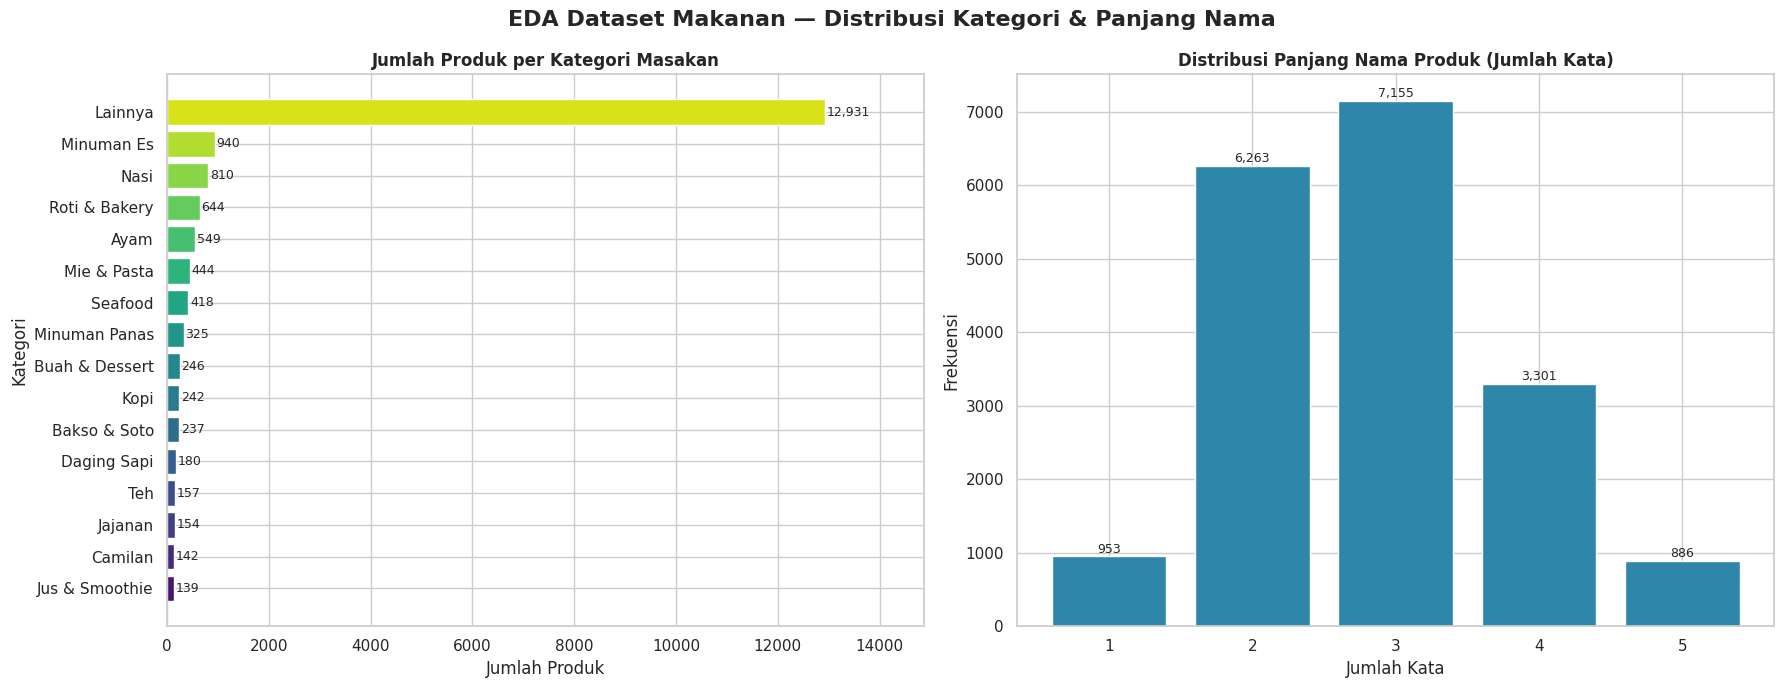

In [5]:
# ── Grafik: Distribusi Kategori & Panjang Nama Produk ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("EDA Dataset Makanan — Distribusi Kategori & Panjang Nama",
             fontsize=16, fontweight="bold")

# ── Kiri: Distribusi per Kategori (bar horizontal) ───────────────────────────
df_kat = df_food["kategori"].value_counts().reset_index()
df_kat.columns = ["Kategori", "Jumlah"]
df_kat = df_kat.sort_values("Jumlah", ascending=True)

colors_kat = sns.color_palette("viridis", len(df_kat))
bars = axes[0].barh(df_kat["Kategori"], df_kat["Jumlah"], color=colors_kat)
axes[0].set_title("Jumlah Produk per Kategori Masakan", fontweight="bold")
axes[0].set_xlabel("Jumlah Produk")
axes[0].set_ylabel("Kategori")
# Label angka di ujung bar
for bar, val in zip(bars, df_kat["Jumlah"]):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", ha="left", fontsize=9)
axes[0].set_xlim(0, df_kat["Jumlah"].max() * 1.15)

# ── Kanan: Distribusi panjang nama (jumlah kata) ──────────────────────────────
panjang_dist = df_food["panjang_nama"].value_counts().sort_index().head(10)
axes[1].bar(panjang_dist.index.astype(str), panjang_dist.values,
            color=WARNA_1, edgecolor="white")
axes[1].set_title("Distribusi Panjang Nama Produk (Jumlah Kata)", fontweight="bold")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
for i, val in enumerate(panjang_dist.values):
    axes[1].text(i, val + 50, f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot_2a_distribusi_kategori.png", dpi=120, bbox_inches="tight")
plt.show()

**Top 20 Kata Pertama Nama Produk**

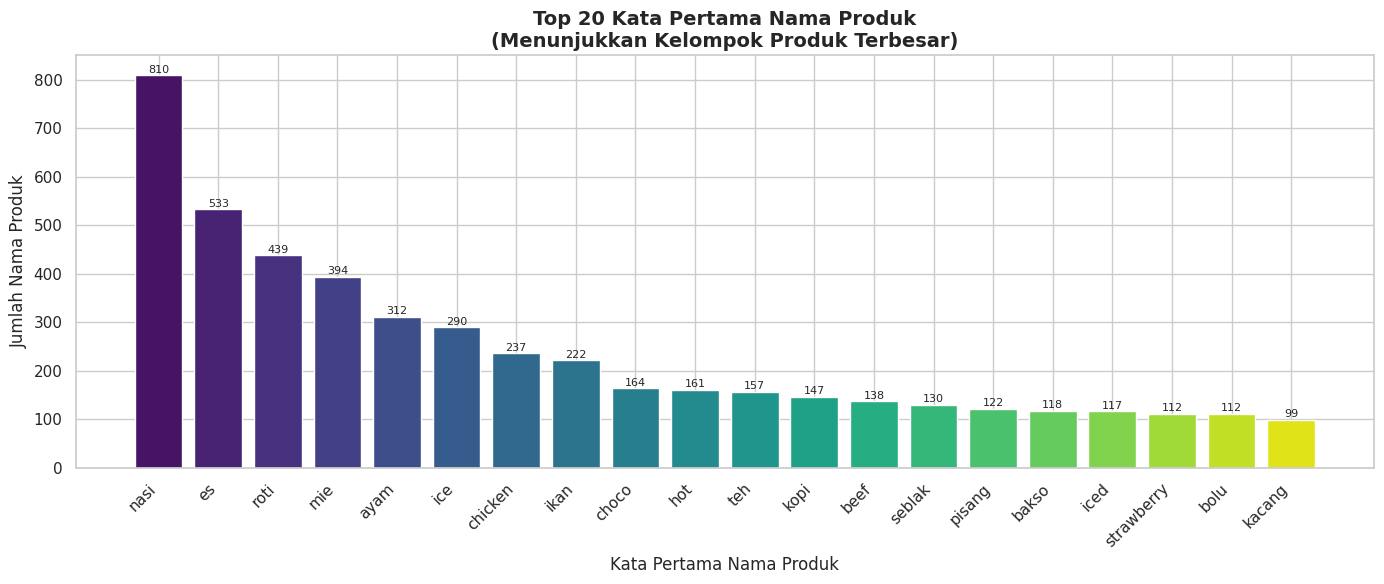

In [6]:
# ── Grafik: Top 20 kata pertama (proxy kelompok produk terbesar) ──────────────
top20_kata = df_food["name_clean"].str.split().str[0].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top20_kata.index, top20_kata.values,
              color=sns.color_palette("viridis", 20), edgecolor="white")
ax.set_title("Top 20 Kata Pertama Nama Produk\n(Menunjukkan Kelompok Produk Terbesar)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Kata Pertama Nama Produk")
ax.set_ylabel("Jumlah Nama Produk")
plt.xticks(rotation=45, ha="right")
# Label angka di atas bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(bar.get_height()), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("plot_2b_top20_kata_produk.png", dpi=120, bbox_inches="tight")
plt.show()

**Load & Inspeksi Dataset Slang**

In [7]:
# ── Load dataset slang ────────────────────────────────────────────────────────
df_slang = pd.read_csv("slang_utama.csv")

print("── Ukuran Dataset ───────────────────────────────")
print(f"  Baris  : {len(df_slang):,}")
print(f"  Kolom  : {df_slang.columns.tolist()}")
print()
print("── 10 Baris Pertama ─────────────────────────────")
print(df_slang.head(10))
print()
print("── Missing Value ────────────────────────────────")
print(df_slang.isnull().sum())
print()
print("── Duplikat pada kolom 'slang' ──────────────────")
print(f"  Jumlah duplikat: {df_slang['slang'].duplicated().sum()}")

── Ukuran Dataset ───────────────────────────────
  Baris  : 1,231
  Kolom  : ['slang', 'formal']

── 10 Baris Pertama ─────────────────────────────
      slang    formal
0        aa     kakak
1   abanggg     abang
2  abanggku   abangku
3    abeees     habis
4      abes     habis
5      abez     habis
6       abg     abang
7    abgnya  abangnya
8  abgnyaah  abangnya
9     abiez     habis

── Missing Value ────────────────────────────────
slang     0
formal    0
dtype: int64

── Duplikat pada kolom 'slang' ──────────────────
  Jumlah duplikat: 0


**Rekayasa Fitur & Analisis Dataset Slang**

In [8]:
# ── Hitung panjang karakter dan selisihnya ────────────────────────────────────
df_slang["panjang_slang"]   = df_slang["slang"].str.len()
df_slang["panjang_formal"]  = df_slang["formal"].str.len()
df_slang["selisih_panjang"] = df_slang["panjang_formal"] - df_slang["panjang_slang"]

# Tipe slang: lebih pendek, sama, atau lebih panjang?
def tipe_slang(selisih):
    if selisih > 0:
        return "Disingkat"
    elif selisih == 0:
        return "Sama panjang"
    else:
        return "Diperpanjang"

df_slang["tipe"] = df_slang["selisih_panjang"].apply(tipe_slang)

print("── Distribusi Tipe Slang ────────────────────────")
print(df_slang["tipe"].value_counts())
print()
print("── 10 Slang yang Paling Banyak Disingkat ────────")
print(df_slang.nlargest(10, "selisih_panjang")[["slang","formal","selisih_panjang"]])
print()
print("── Kata Formal dengan Variasi Slang Terbanyak ───")
print(df_slang["formal"].value_counts().head(10))

── Distribusi Tipe Slang ────────────────────────
tipe
Disingkat       767
Diperpanjang    288
Sama panjang    176
Name: count, dtype: int64

── 10 Slang yang Paling Banyak Disingkat ────────
    slang                              formal  selisih_panjang
362   ibf  international badminton federation               31
47    akk    administrasi kebijakan kesehatan               29
387   ite      informasi transaksi elektronik               27
265   fkm       fakultas kesehatan masyarakat               26
147   bsn         badan standarisasi nasional               24
133   bpd          badan permusyawaratan desa               23
358  http         hypertext transfer protocol               23
508   lsm          lembaga swadaya masyarakat               23
91    bem           badan eksekutif mahasiswa               22
116   bnn            badan narkotika nasional               21

── Kata Formal dengan Variasi Slang Terbanyak ───
formal
iya        66
tidak      50
ingin      31
kakak      30
s

**Visualisasi Dataset Slang**

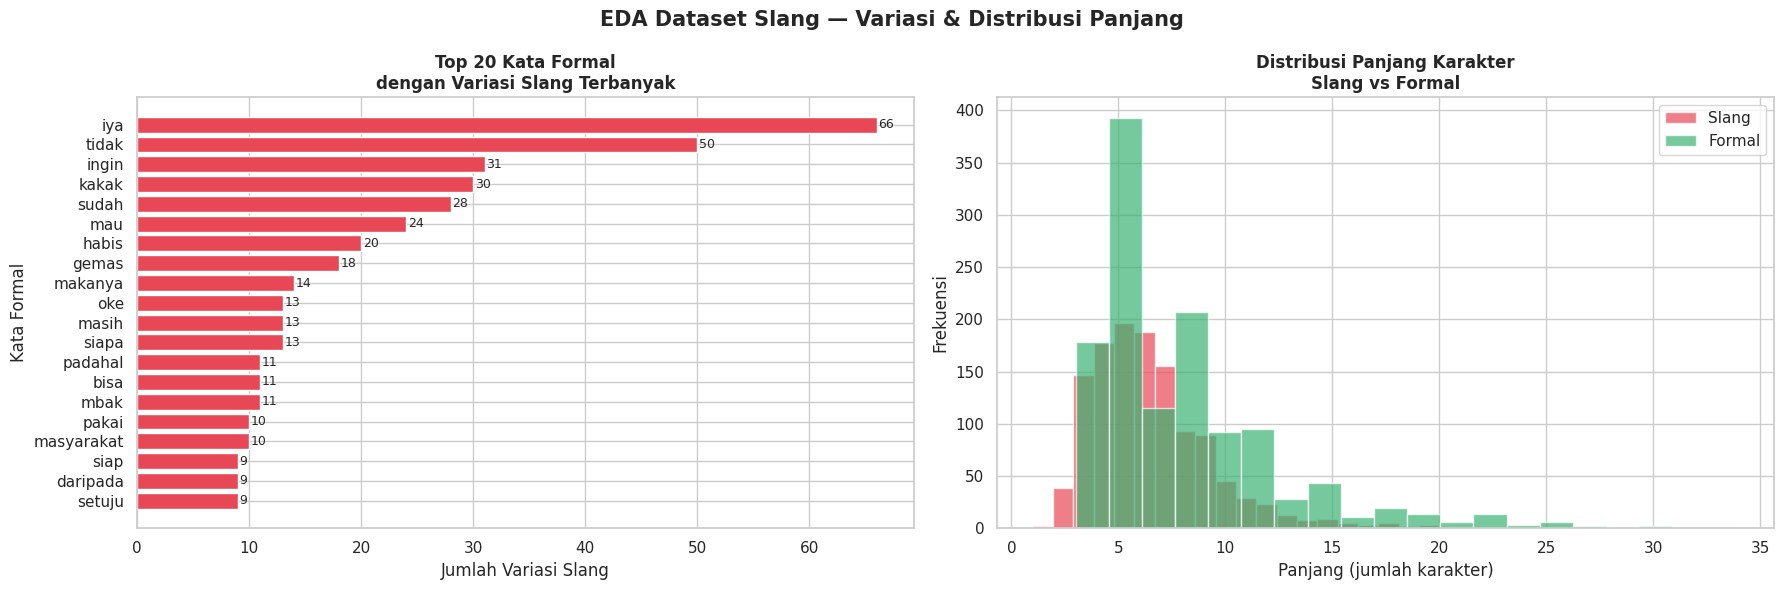

In [9]:
# ── Grafik: Top variasi slang & distribusi panjang ───────────────────────────
variasi_per_formal = df_slang["formal"].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("EDA Dataset Slang — Variasi & Distribusi Panjang",
             fontsize=15, fontweight="bold")

# ── Kiri: Top-20 kata formal dengan variasi slang terbanyak ──────────────────
bars = axes[0].barh(variasi_per_formal.index[::-1],
                    variasi_per_formal.values[::-1],
                    color=WARNA_2, edgecolor="white")
axes[0].set_title("Top 20 Kata Formal\ndengan Variasi Slang Terbanyak", fontweight="bold")
axes[0].set_xlabel("Jumlah Variasi Slang")
axes[0].set_ylabel("Kata Formal")
for bar, val in zip(bars, variasi_per_formal.values[::-1]):
    axes[0].text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=9)

# ── Kanan: Distribusi panjang karakter slang vs formal ───────────────────────
axes[1].hist(df_slang["panjang_slang"], bins=20, alpha=0.7,
             label="Slang", color=WARNA_2, edgecolor="white")
axes[1].hist(df_slang["panjang_formal"], bins=20, alpha=0.7,
             label="Formal", color=WARNA_3, edgecolor="white")
axes[1].set_title("Distribusi Panjang Karakter\nSlang vs Formal", fontweight="bold")
axes[1].set_xlabel("Panjang (jumlah karakter)")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_3a_eda_slang.png", dpi=120, bbox_inches="tight")
plt.show()

**Kata Slang dalam Percakapan**

In [10]:
# ── Hitung kemunculan kata slang di teks obrolan pelanggan ───────────────────
df_synth  = pd.read_csv("chatkasir_synthetic.csv")
set_slang = set(df_slang["slang"].str.lower())

def ekstrak_teks_customer(teks):
    """Ambil bagian percakapan pelanggan (sebelum [SEP])."""
    return teks.split("[SEP]")[0].lower()

# Proses sample 10.000 baris agar cepat
sample_teks = df_synth["input_text"].sample(10000, random_state=42)
semua_kata  = []
for teks in sample_teks:
    semua_kata.extend(re.findall(r"\b\w+\b", ekstrak_teks_customer(teks)))

# Filter hanya kata yang ada di kamus slang
kata_slang_muncul = [k for k in semua_kata if k in set_slang]
counter_slang     = Counter(kata_slang_muncul)

print(f"Total kemunculan kata slang (10.000 sampel): {len(kata_slang_muncul):,}")
print()
print("── Top 20 Kata Slang Paling Sering Muncul ───────")
for kata, freq in counter_slang.most_common(20):
    formal = df_slang.loc[df_slang["slang"] == kata, "formal"].values
    formal_str = formal[0] if len(formal) > 0 else "-"
    print(f"  '{kata}' → '{formal_str}' : {freq}x")

Total kemunculan kata slang (10.000 sampel): 16,966

── Top 20 Kata Slang Paling Sering Muncul ───────
  'kak' → 'kakak' : 5209x
  'mau' → 'ingin memesan' : 2222x
  'pesen' → 'pesan' : 1681x
  'order' → 'pesan' : 1173x
  'gak' → 'tidak' : 729x
  'pake' → 'pakai' : 729x
  'anget' → 'hangat' : 708x
  'pedes' → 'pedas' : 687x
  'minta' → 'meminta' : 470x
  'bu' → 'ibu' : 426x
  'kk' → 'kakak' : 414x
  'bang' → 'abang' : 412x
  'min' → 'admin' : 410x
  'mbak' → 'mbak-mbak' : 398x
  'pak' → 'bapak' : 389x
  'rp' → 'rupiah' : 186x
  'plus' → 'tambah' : 63x
  'dingin' → 'dingin-dingin' : 44x
  'dipacking' → 'dibungkus' : 44x
  'no' → 'tidak' : 32x


**Visualisasi Top Slang dalam Percakapan**

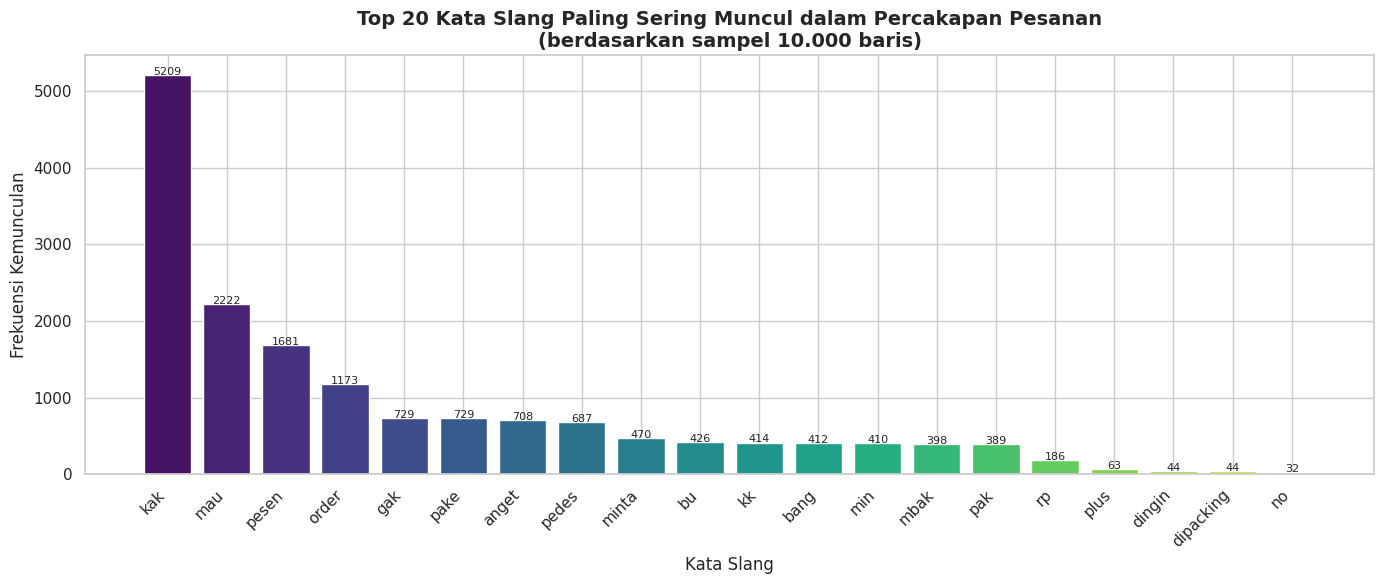

In [11]:
# ── Grafik: Top 20 kata slang yang aktif di percakapan ───────────────────────
top20_slang = pd.DataFrame(counter_slang.most_common(20),
                           columns=["kata_slang", "frekuensi"])

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top20_slang["kata_slang"], top20_slang["frekuensi"],
              color=sns.color_palette("viridis", 20), edgecolor="white")
ax.set_title("Top 20 Kata Slang Paling Sering Muncul dalam Percakapan Pesanan\n"
             "(berdasarkan sampel 10.000 baris)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Kata Slang")
ax.set_ylabel("Frekuensi Kemunculan")
plt.xticks(rotation=45, ha="right")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(bar.get_height()), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("plot_3b_top20_slang_percakapan.png", dpi=120, bbox_inches="tight")
plt.show()

**Load & Inspeksi Data Sintetis**

In [12]:
# ── df_synth sudah di-load di Cell 9, langsung pakai ─────────────────────────
print("── Ukuran Dataset ───────────────────────────────")
print(f"  Baris  : {len(df_synth):,}")
print(f"  Kolom  : {df_synth.columns.tolist()}")
print()
print("── Tipe Data ────────────────────────────────────")
print(df_synth.dtypes)
print()
print("── 3 Baris Pertama ──────────────────────────────")
print(df_synth.head(3).to_string())
print()
print("── Missing Value ────────────────────────────────")
print(df_synth.isnull().sum())
print()
print("── Distribusi Kolom 'pattern' ───────────────────")
print(df_synth["pattern"].value_counts().sort_index())

── Ukuran Dataset ───────────────────────────────
  Baris  : 100,000
  Kolom  : ['input_text', 'product', 'quantity', 'price_satuan', 'pattern']

── Tipe Data ────────────────────────────────────
input_text      object
product         object
quantity        object
price_satuan     int64
pattern          int64
dtype: object

── 3 Baris Pertama ──────────────────────────────
                                                                                                                                                                        input_text                                product            quantity  price_satuan  pattern
0  pesan nasi goreng babi setengah porsi dan kailan daging ayam segelas porsi ya kak [SEP] siap kak, nasi goreng babi rp 58.000 dan kailan daging ayam 54rb, jadi total rp112rb ya  nasi goreng babi & kailan daging ayam  setengah & segelas            -1        4
1                                                                              pesen nasgor sei ayam n

**Rekayasa Fitur Data Sintetis**

In [13]:
# ── Tambah kolom-kolom turunan ────────────────────────────────────────────────

# Apakah harga disebutkan? (price_satuan == -1 berarti tidak disebutkan)
df_synth["harga_eksplisit"] = df_synth["price_satuan"] != -1

# Apakah pesanan berisi lebih dari 1 produk?
df_synth["multi_produk"] = df_synth["product"].str.contains(" & ", na=False)

# Apakah kuantitas berupa angka murni?
df_synth["qty_numerik"] = pd.to_numeric(
    df_synth["quantity"], errors="coerce").notna()

# Segmentasi harga berdasarkan rentang harga
def segmen_harga(harga):
    if harga == -1:
        return "Tidak disebutkan"
    elif harga < 15000:
        return "Murah (< 15rb)"
    elif harga < 35000:
        return "Sedang (15rb–35rb)"
    elif harga < 60000:
        return "Agak Mahal (35rb–60rb)"
    else:
        return "Mahal (≥ 60rb)"

df_synth["segmen_harga"] = df_synth["price_satuan"].apply(segmen_harga)

# ── Ringkasan fitur baru ──────────────────────────────────────────────────────
print("── Ringkasan Fitur Turunan ──────────────────────")
print(f"  Harga eksplisit      : {df_synth['harga_eksplisit'].sum():>7,} "
      f"({df_synth['harga_eksplisit'].mean()*100:.1f}%)")
print(f"  Pesanan multi-produk : {df_synth['multi_produk'].sum():>7,} "
      f"({df_synth['multi_produk'].mean()*100:.1f}%)")
print(f"  Kuantitas numerik    : {df_synth['qty_numerik'].sum():>7,} "
      f"({df_synth['qty_numerik'].mean()*100:.1f}%)")
print()
print("── Distribusi Segmen Harga ──────────────────────")
print(df_synth["segmen_harga"].value_counts())

── Ringkasan Fitur Turunan ──────────────────────
  Harga eksplisit      :  66,070 (66.1%)
  Pesanan multi-produk :  20,000 (20.0%)
  Kuantitas numerik    :  40,071 (40.1%)

── Distribusi Segmen Harga ──────────────────────
segmen_harga
Tidak disebutkan          33930
Agak Mahal (35rb–60rb)    22393
Sedang (15rb–35rb)        18149
Mahal (≥ 60rb)            14496
Murah (< 15rb)            11032
Name: count, dtype: int64


**Visualisasi EDA Data Sintetis**

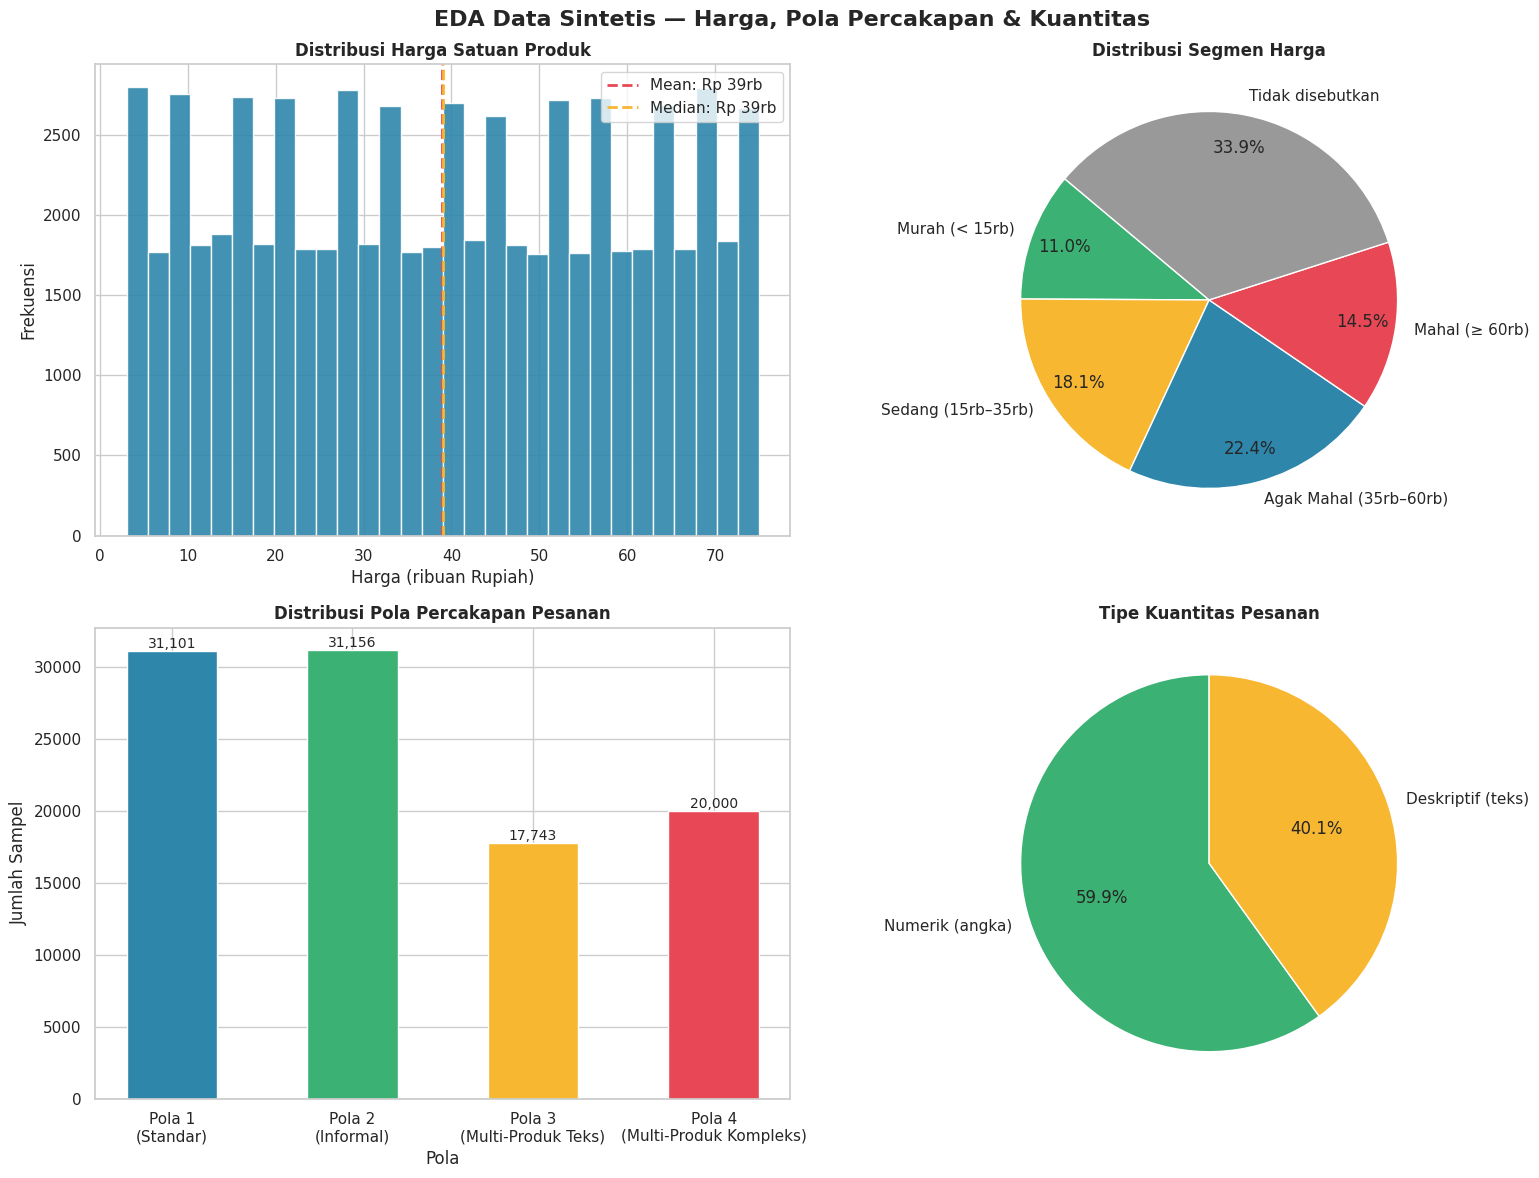

In [14]:
# ── Grafik 4 panel: harga, segmen, pola, kuantitas ───────────────────────────
df_harga = df_synth[df_synth["harga_eksplisit"]].copy()   # hanya baris ada harga

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA Data Sintetis — Harga, Pola Percakapan & Kuantitas",
             fontsize=16, fontweight="bold")

# ── (1) Histogram harga satuan ────────────────────────────────────────────────
axes[0, 0].hist(df_harga["price_satuan"] / 1000, bins=30,
                color=WARNA_1, edgecolor="white", alpha=0.9)
axes[0, 0].axvline(df_harga["price_satuan"].mean() / 1000,
                   color=WARNA_2, linestyle="--", linewidth=2,
                   label=f"Mean: Rp {df_harga['price_satuan'].mean()/1000:.0f}rb")
axes[0, 0].axvline(df_harga["price_satuan"].median() / 1000,
                   color=WARNA_4, linestyle="--", linewidth=2,
                   label=f"Median: Rp {df_harga['price_satuan'].median()/1000:.0f}rb")
axes[0, 0].set_title("Distribusi Harga Satuan Produk", fontweight="bold")
axes[0, 0].set_xlabel("Harga (ribuan Rupiah)")
axes[0, 0].set_ylabel("Frekuensi")
axes[0, 0].legend()

# ── (2) Pie chart segmen harga ────────────────────────────────────────────────
urutan_segmen = ["Murah (< 15rb)", "Sedang (15rb–35rb)",
                 "Agak Mahal (35rb–60rb)", "Mahal (≥ 60rb)", "Tidak disebutkan"]
segmen_counts = df_synth["segmen_harga"].value_counts().reindex(urutan_segmen).dropna()
colors_pie    = [WARNA_3, WARNA_4, WARNA_1, WARNA_2, "#999999"]
axes[0, 1].pie(segmen_counts.values,
               labels=segmen_counts.index,
               autopct="%1.1f%%",
               colors=colors_pie[:len(segmen_counts)],
               startangle=140, pctdistance=0.82)
axes[0, 1].set_title("Distribusi Segmen Harga", fontweight="bold")

# ── (3) Bar chart distribusi pola percakapan ──────────────────────────────────
pola_desc   = {1: "Pola 1\n(Standar)", 2: "Pola 2\n(Informal)",
               3: "Pola 3\n(Multi-Produk Teks)", 4: "Pola 4\n(Multi-Produk Kompleks)"}
pola_counts = df_synth["pattern"].value_counts().sort_index()
pola_labels = [pola_desc[i] for i in pola_counts.index]
axes[1, 0].bar(pola_labels, pola_counts.values,
               color=[WARNA_1, WARNA_3, WARNA_4, WARNA_2],
               edgecolor="white", width=0.5)
axes[1, 0].set_title("Distribusi Pola Percakapan Pesanan", fontweight="bold")
axes[1, 0].set_xlabel("Pola")
axes[1, 0].set_ylabel("Jumlah Sampel")
for i, val in enumerate(pola_counts.values):
    axes[1, 0].text(i, val + 200, f"{val:,}", ha="center", fontsize=10)

# ── (4) Pie chart kuantitas numerik vs teks ───────────────────────────────────
qty_counts = df_synth["qty_numerik"].value_counts()
axes[1, 1].pie(qty_counts.values,
               labels=["Numerik (angka)", "Deskriptif (teks)"],
               autopct="%1.1f%%",
               colors=[WARNA_3, WARNA_4], startangle=90)
axes[1, 1].set_title("Tipe Kuantitas Pesanan", fontweight="bold")

plt.tight_layout()
plt.savefig("plot_4a_eda_sintetis.png", dpi=120, bbox_inches="tight")
plt.show()

**PB-1: Top 25 Produk Terlaris**

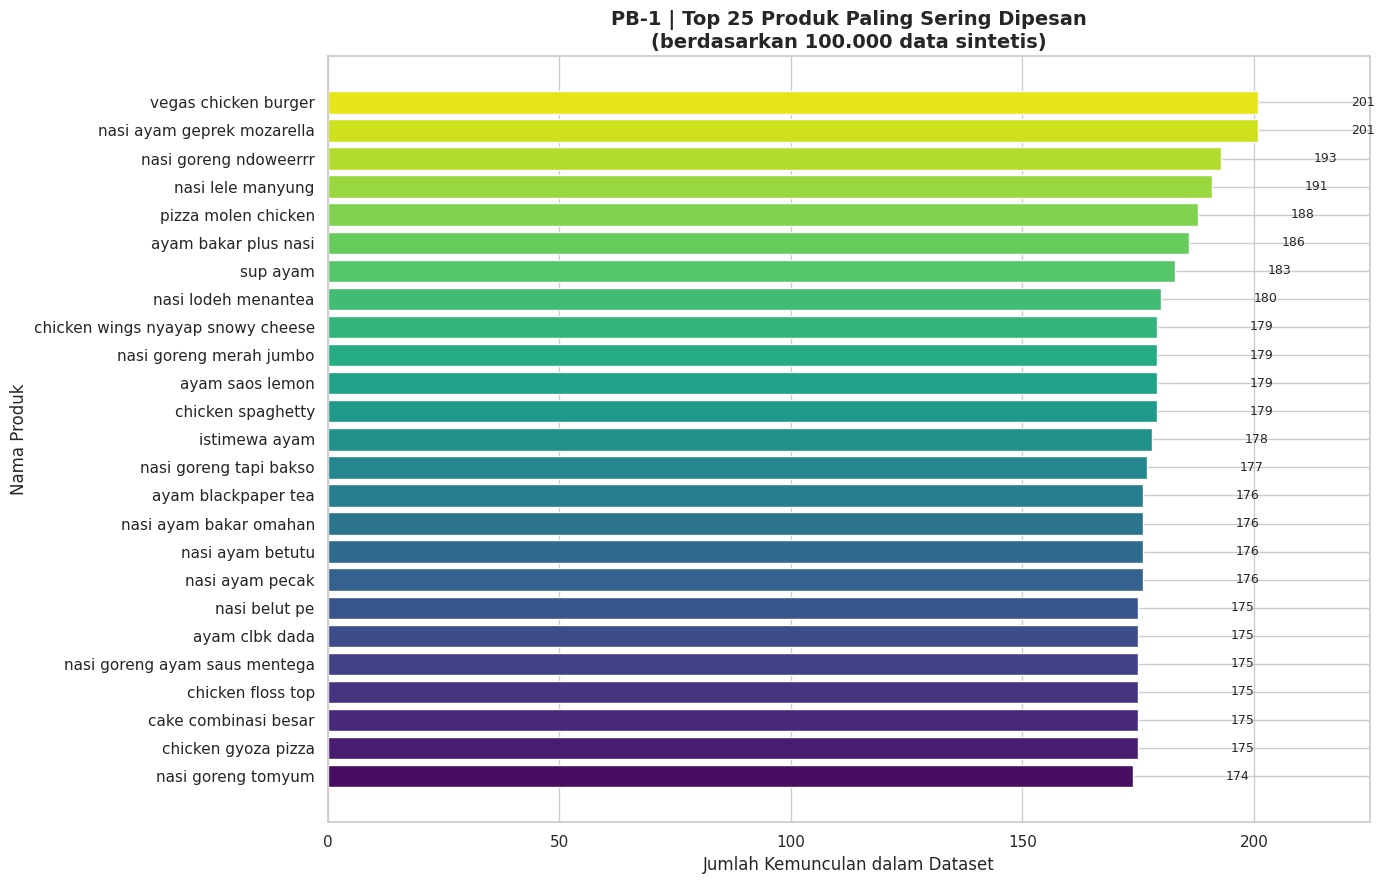

✅ Produk terlaris: 'vegas chicken burger' (201x)


In [15]:
# ── PB-1 | Pisahkan multi-produk lalu hitung frekuensi ───────────────────────
def pisah_produk(teks):
    """Pisahkan string multi-produk menjadi list produk tunggal."""
    return [p.strip() for p in str(teks).split(" & ")]

semua_produk = (df_synth["product"]
                .dropna()
                .apply(pisah_produk)
                .explode()
                .str.strip()
                .str.lower())

top25_produk = semua_produk.value_counts().head(25)

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(top25_produk.index[::-1], top25_produk.values[::-1],
               color=sns.color_palette("viridis", 25), edgecolor="white")
ax.set_title("PB-1 | Top 25 Produk Paling Sering Dipesan\n"
             "(berdasarkan 100.000 data sintetis)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Jumlah Kemunculan dalam Dataset")
ax.set_ylabel("Nama Produk")
for bar, val in zip(bars, top25_produk.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)
ax.set_xlim(0, top25_produk.max() * 1.12)

plt.tight_layout()
plt.savefig("plot_5a_pb1_top_produk.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Produk terlaris: '{top25_produk.index[0]}' ({top25_produk.iloc[0]:,}x)")

**PB-2: Analisis Rata-rata Nilai Transaksi**

══════════════════════════════════════════════════
  PB-2 | RINGKASAN NILAI TRANSAKSI
══════════════════════════════════════════════════
  Total transaksi  :     66,070
  Rata-rata (mean) : Rp     38,883
  Median           : Rp     39,000
  Standar Deviasi  : Rp     21,133
  Min              : Rp      3,000
  Max              : Rp     75,000
══════════════════════════════════════════════════


/tmp/ipykernel_587/1094985114.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_harga, x="pola_label", y="price_satuan",
/tmp/ipykernel_587/1094985114.py:33: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.violinplot(data=df_harga, x="pola_label", y="price_satuan",


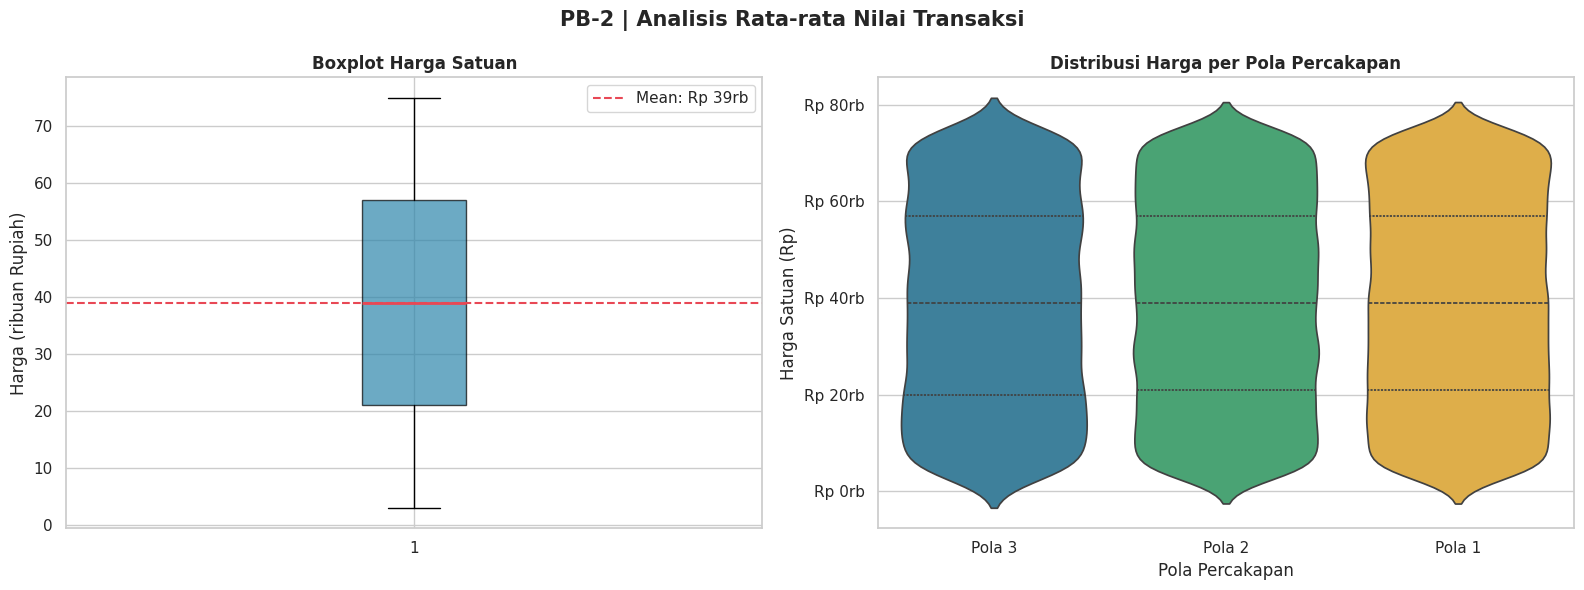

In [16]:
# ── PB-2 | Statistik harga & visualisasi boxplot + violin ────────────────────
df_harga = df_synth[df_synth["harga_eksplisit"]].copy()

print("═" * 50)
print("  PB-2 | RINGKASAN NILAI TRANSAKSI")
print("═" * 50)
print(f"  Total transaksi  : {len(df_harga):>10,}")
print(f"  Rata-rata (mean) : Rp {df_harga['price_satuan'].mean():>10,.0f}")
print(f"  Median           : Rp {df_harga['price_satuan'].median():>10,.0f}")
print(f"  Standar Deviasi  : Rp {df_harga['price_satuan'].std():>10,.0f}")
print(f"  Min              : Rp {df_harga['price_satuan'].min():>10,.0f}")
print(f"  Max              : Rp {df_harga['price_satuan'].max():>10,.0f}")
print("═" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PB-2 | Analisis Rata-rata Nilai Transaksi", fontsize=15, fontweight="bold")

# ── Kiri: Boxplot ─────────────────────────────────────────────────────────────
axes[0].boxplot(df_harga["price_satuan"] / 1000, vert=True,
                patch_artist=True,
                boxprops=dict(facecolor=WARNA_1, alpha=0.7),
                medianprops=dict(color=WARNA_2, linewidth=2))
axes[0].set_title("Boxplot Harga Satuan", fontweight="bold")
axes[0].set_ylabel("Harga (ribuan Rupiah)")
axes[0].axhline(df_harga["price_satuan"].mean() / 1000,
                color=WARNA_2, linestyle="--", linewidth=1.5,
                label=f"Mean: Rp {df_harga['price_satuan'].mean()/1000:.0f}rb")
axes[0].legend()

# ── Kanan: Violin plot per pola percakapan ────────────────────────────────────
pola_map = {1: "Pola 1", 2: "Pola 2", 3: "Pola 3", 4: "Pola 4"}
df_harga["pola_label"] = df_harga["pattern"].map(pola_map)
sns.violinplot(data=df_harga, x="pola_label", y="price_satuan",
               palette=[WARNA_1, WARNA_3, WARNA_4, WARNA_2],
               inner="quartile", ax=axes[1])
axes[1].set_title("Distribusi Harga per Pola Percakapan", fontweight="bold")
axes[1].set_xlabel("Pola Percakapan")
axes[1].set_ylabel("Harga Satuan (Rp)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rp {x/1000:.0f}rb"))

plt.tight_layout()
plt.savefig("plot_5b_pb2_transaksi.png", dpi=120, bbox_inches="tight")
plt.show()

**PB-3: Distribusi Segmen Harga**

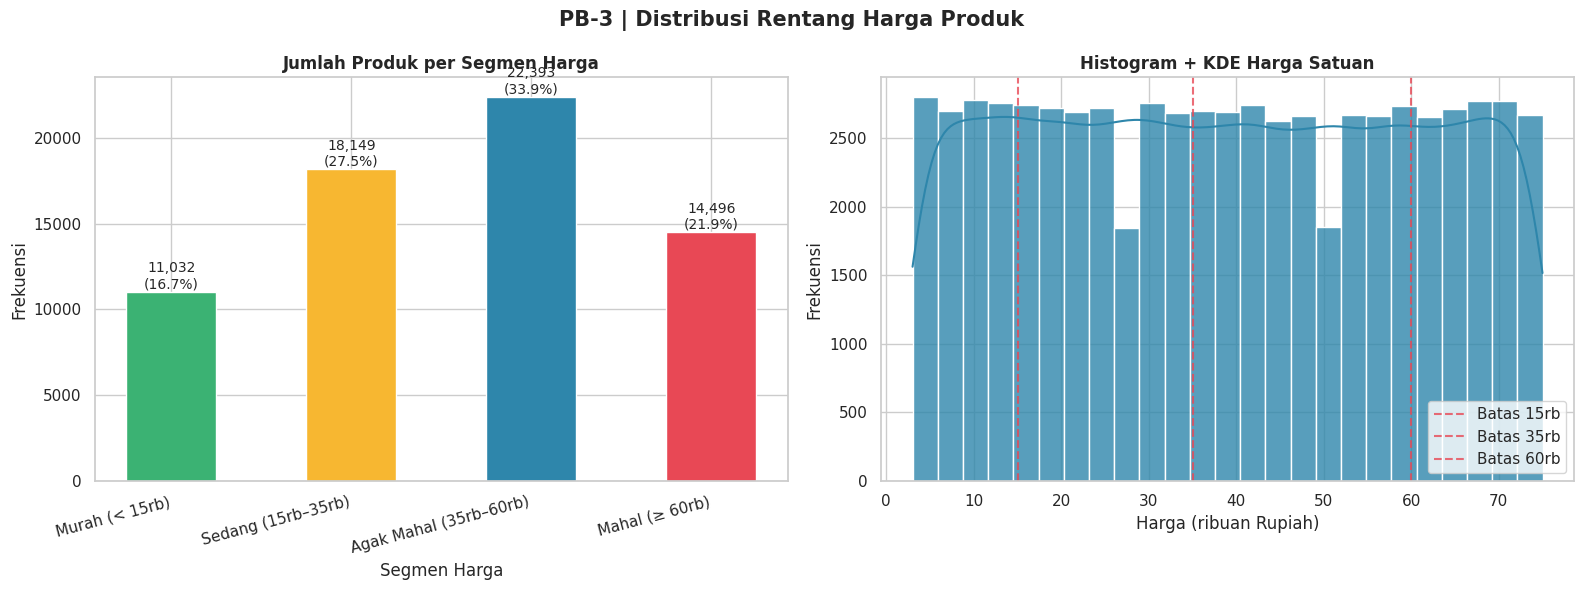

In [17]:
# ── PB-3 | Bar segmen harga + histogram KDE ───────────────────────────────────
urutan   = ["Murah (< 15rb)", "Sedang (15rb–35rb)",
            "Agak Mahal (35rb–60rb)", "Mahal (≥ 60rb)"]
df_seg   = df_harga["segmen_harga"].value_counts().reindex(urutan).fillna(0)
pct_seg  = (df_seg / df_seg.sum() * 100).round(1)
warna_seg = [WARNA_3, WARNA_4, WARNA_1, WARNA_2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PB-3 | Distribusi Rentang Harga Produk", fontsize=15, fontweight="bold")

# ── Kiri: Bar chart per segmen ────────────────────────────────────────────────
bars = axes[0].bar(df_seg.index, df_seg.values,
                   color=warna_seg, edgecolor="white", width=0.5)
axes[0].set_title("Jumlah Produk per Segmen Harga", fontweight="bold")
axes[0].set_xlabel("Segmen Harga")
axes[0].set_ylabel("Frekuensi")
plt.setp(axes[0].get_xticklabels(), rotation=15, ha="right")
for bar, pct in zip(bars, pct_seg.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 200,
                 f"{bar.get_height():,.0f}\n({pct}%)",
                 ha="center", fontsize=10)

# ── Kanan: Histogram + KDE ────────────────────────────────────────────────────
sns.histplot(df_harga["price_satuan"] / 1000, bins=25,
             kde=True, color=WARNA_1, ax=axes[1],
             edgecolor="white", alpha=0.8)
axes[1].set_title("Histogram + KDE Harga Satuan", fontweight="bold")
axes[1].set_xlabel("Harga (ribuan Rupiah)")
axes[1].set_ylabel("Frekuensi")
# Garis batas segmen
for batas, label in [(15, "15rb"), (35, "35rb"), (60, "60rb")]:
    axes[1].axvline(batas, color=WARNA_2, linestyle="--",
                    linewidth=1.5, alpha=0.8, label=f"Batas {label}")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_5c_pb3_segmen_harga.png", dpi=120, bbox_inches="tight")
plt.show()

**PB-4: Pola Kalimat Percakapan**

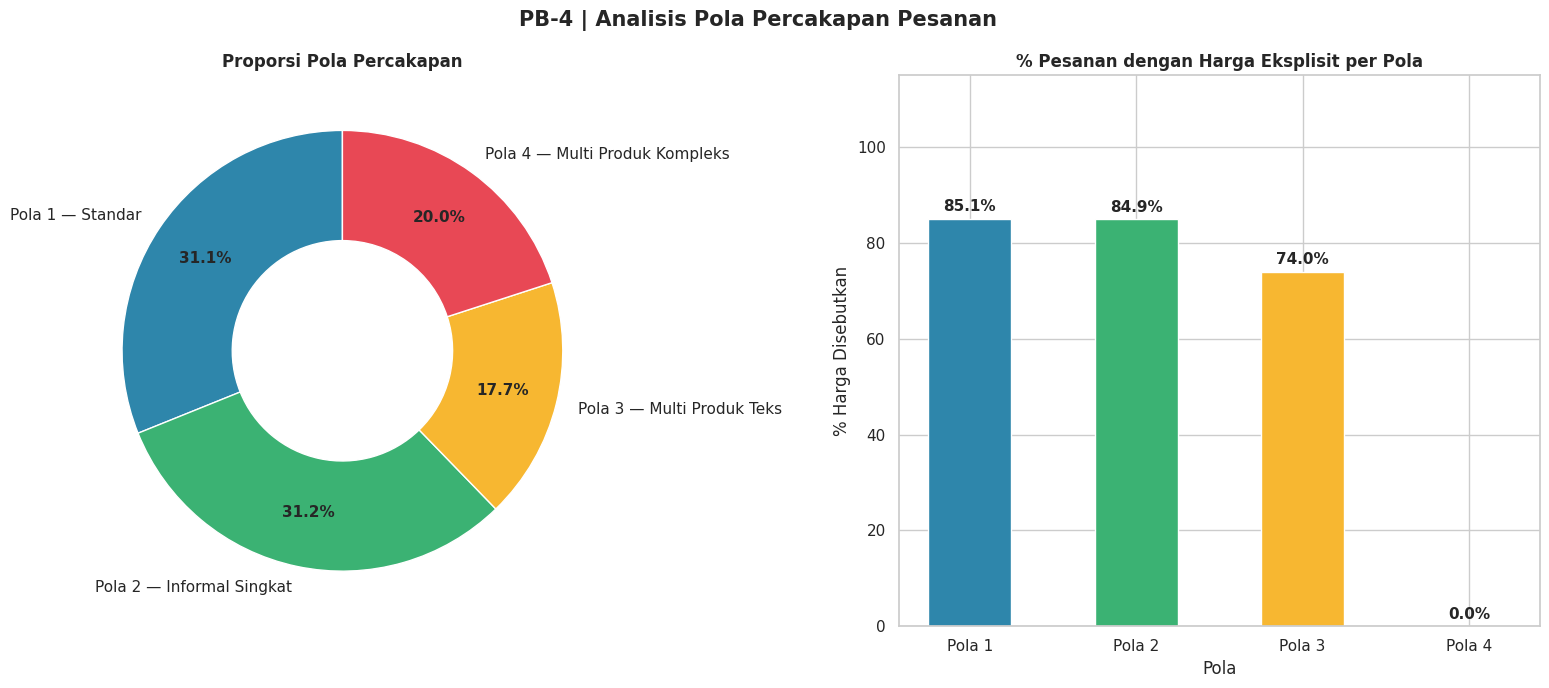

In [18]:
# ── PB-4 | Donut pola + % harga eksplisit per pola ───────────────────────────
pola_detail = {
    1: ("Pola 1 — Standar",         WARNA_1),
    2: ("Pola 2 — Informal Singkat",WARNA_3),
    3: ("Pola 3 — Multi Produk Teks",WARNA_4),
    4: ("Pola 4 — Multi Produk Kompleks", WARNA_2),
}
pola_count = df_synth["pattern"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("PB-4 | Analisis Pola Percakapan Pesanan", fontsize=15, fontweight="bold")

# ── Kiri: Donut chart ────────────────────────────────────────────────────────
labels_d = [pola_detail[i][0] for i in pola_count.index]
colors_d = [pola_detail[i][1] for i in pola_count.index]
wedges, texts, autotexts = axes[0].pie(
    pola_count.values, labels=labels_d, autopct="%1.1f%%",
    colors=colors_d, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5))           # donut berlubang
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
axes[0].set_title("Proporsi Pola Percakapan", fontweight="bold")

# ── Kanan: % harga eksplisit per pola ────────────────────────────────────────
pola_harga   = df_synth.groupby("pattern")["harga_eksplisit"].mean() * 100
pola_x_label = [f"Pola {i}" for i in pola_harga.index]
bars = axes[1].bar(pola_x_label, pola_harga.values,
                   color=colors_d, edgecolor="white", width=0.5)
axes[1].set_title("% Pesanan dengan Harga Eksplisit per Pola", fontweight="bold")
axes[1].set_xlabel("Pola")
axes[1].set_ylabel("% Harga Disebutkan")
axes[1].set_ylim(0, 115)
for bar, val in zip(bars, pola_harga.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1.5,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_6a_pb4_pola.png", dpi=120, bbox_inches="tight")
plt.show()

**PB-5: Kata Slang Prioritas AI**

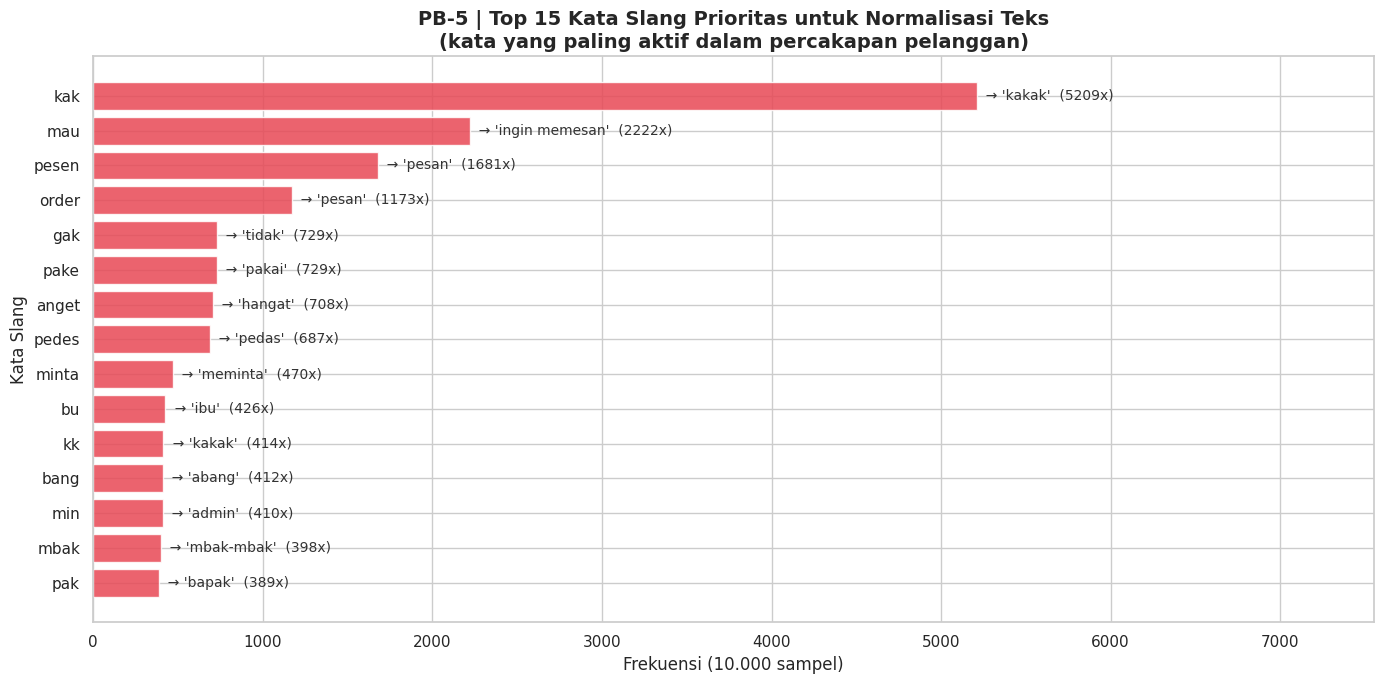

In [19]:
# ── PB-5 | Bar horizontal: top 15 slang + label formal ───────────────────────
top15_slang = pd.DataFrame(counter_slang.most_common(15),
                           columns=["slang", "frekuensi"])
top15_slang["formal"] = top15_slang["slang"].map(
    df_slang.set_index("slang")["formal"])

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top15_slang["slang"][::-1], top15_slang["frekuensi"][::-1],
               color=WARNA_2, edgecolor="white", alpha=0.85)
ax.set_title("PB-5 | Top 15 Kata Slang Prioritas untuk Normalisasi Teks\n"
             "(kata yang paling aktif dalam percakapan pelanggan)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Frekuensi (10.000 sampel)")
ax.set_ylabel("Kata Slang")
# Label formal di sebelah kanan bar
for bar, (_, row) in zip(bars, top15_slang.iloc[::-1].iterrows()):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f"  → '{row['formal']}'  ({row['frekuensi']}x)",
            va="center", fontsize=10, color="#333333")
ax.set_xlim(0, top15_slang["frekuensi"].max() * 1.45)

plt.tight_layout()
plt.savefig("plot_6b_pb5_slang_prioritas.png", dpi=120, bbox_inches="tight")
plt.show()

**PB-6: Harga Eksplisit vs Tidak**

  Harga disebutkan     : 66,070 (66.1%)
  Harga TIDAK disebutkan: 33,930 (33.9%)


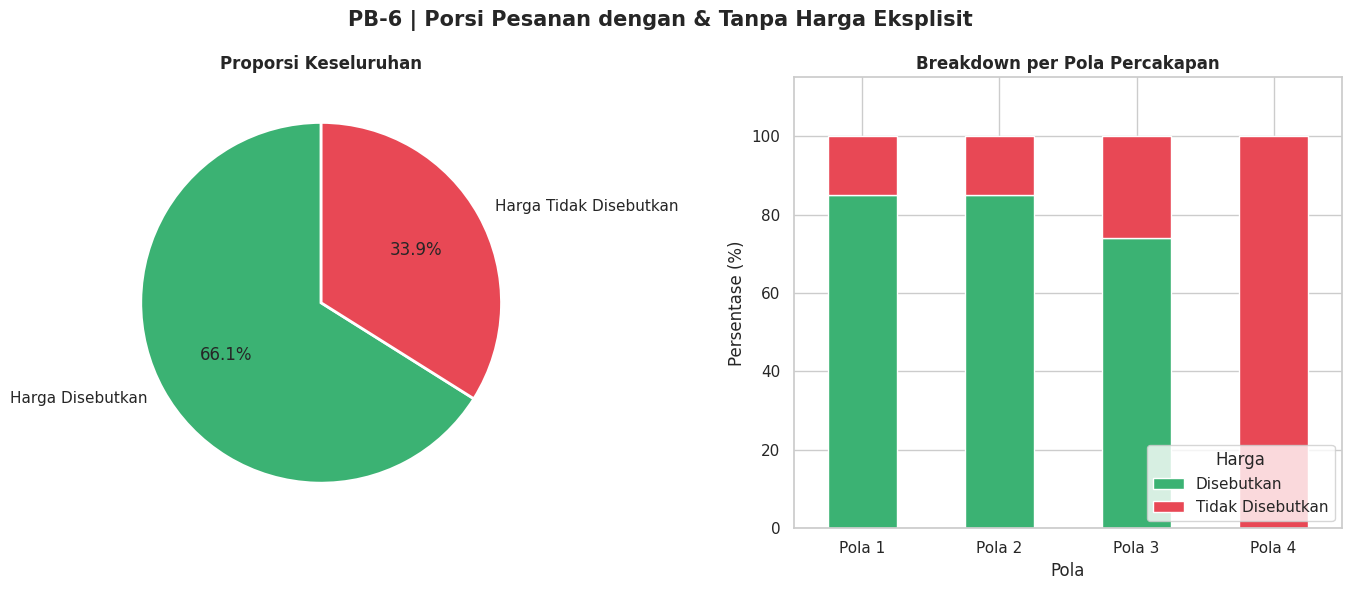

In [20]:
# ── PB-6 | Pie + stacked bar per pola ────────────────────────────────────────
jml_total     = len(df_synth)
jml_eksplisit = df_synth["harga_eksplisit"].sum()
jml_implisit  = jml_total - jml_eksplisit

print(f"  Harga disebutkan     : {jml_eksplisit:,} ({jml_eksplisit/jml_total*100:.1f}%)")
print(f"  Harga TIDAK disebutkan: {jml_implisit:,} ({jml_implisit/jml_total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("PB-6 | Porsi Pesanan dengan & Tanpa Harga Eksplisit",
             fontsize=15, fontweight="bold")

# ── Kiri: Pie chart keseluruhan ───────────────────────────────────────────────
axes[0].pie([jml_eksplisit, jml_implisit],
            labels=["Harga Disebutkan", "Harga Tidak Disebutkan"],
            autopct="%1.1f%%", colors=[WARNA_3, WARNA_2],
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Proporsi Keseluruhan", fontweight="bold")

# ── Kanan: Stacked bar per pola ───────────────────────────────────────────────
pola_breakdown = (df_synth
                  .groupby("pattern")["harga_eksplisit"]
                  .value_counts(normalize=True)
                  .unstack(fill_value=0) * 100)
pola_breakdown.columns   = ["Tidak Disebutkan", "Disebutkan"]
pola_breakdown            = pola_breakdown[["Disebutkan", "Tidak Disebutkan"]]
pola_breakdown.index      = [f"Pola {i}" for i in pola_breakdown.index]
pola_breakdown.plot(kind="bar", stacked=True,
                    color=[WARNA_3, WARNA_2],
                    edgecolor="white", ax=axes[1])
axes[1].set_title("Breakdown per Pola Percakapan", fontweight="bold")
axes[1].set_xlabel("Pola")
axes[1].set_ylabel("Persentase (%)")
axes[1].legend(title="Harga", loc="lower right")
axes[1].set_ylim(0, 115)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("plot_6c_pb6_harga_eksplisit.png", dpi=120, bbox_inches="tight")
plt.show()

**PB-7: Distribusi Tipe Kuantitas**

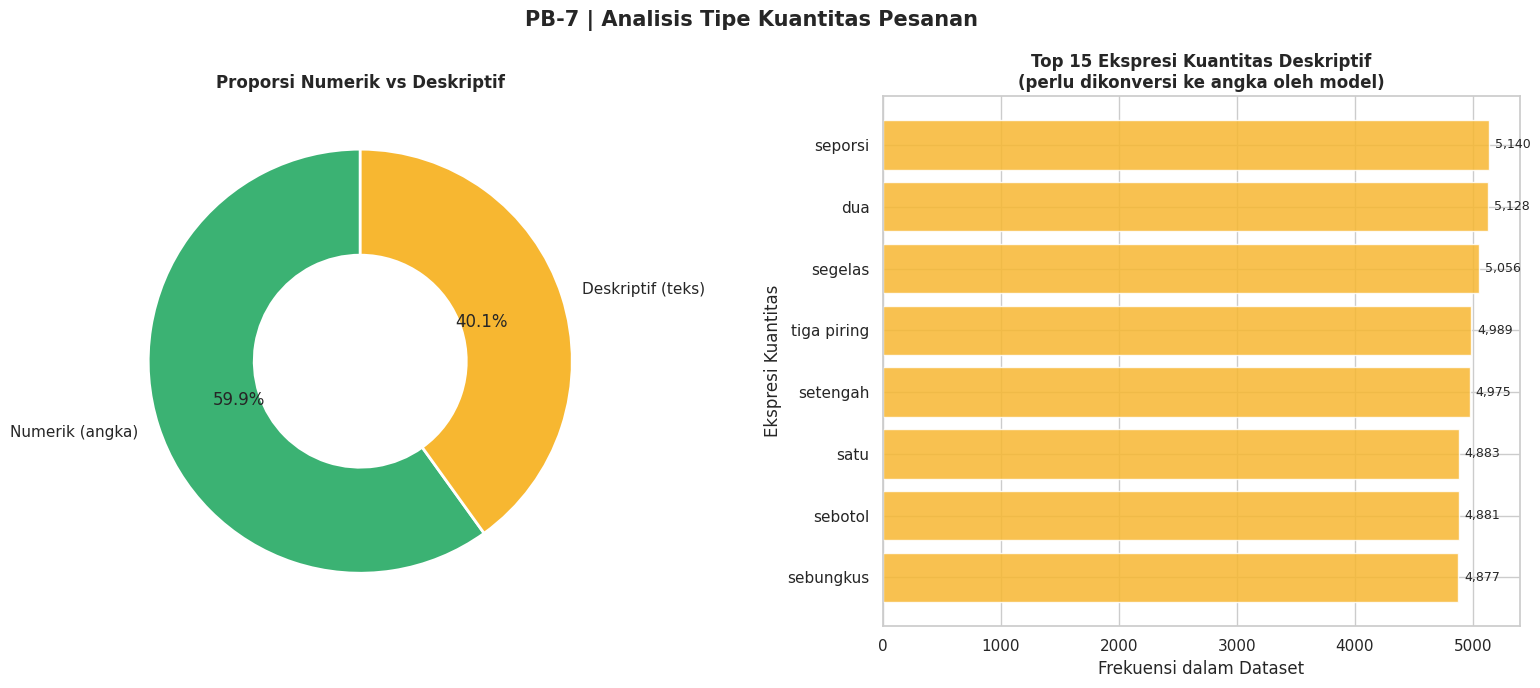

In [21]:
# ── PB-7 | Donut + bar horizontal ekspresi kuantitas deskriptif ───────────────

# Ambil baris dengan qty teks tunggal (bukan multi-produk)
qty_teks    = df_synth.loc[~df_synth["qty_numerik"], "quantity"]
qty_tunggal = qty_teks[~qty_teks.str.contains("&", na=False)]
top_qty     = qty_tunggal.value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("PB-7 | Analisis Tipe Kuantitas Pesanan", fontsize=15, fontweight="bold")

# ── Kiri: Donut proporsi ─────────────────────────────────────────────────────
qty_donut = df_synth["qty_numerik"].value_counts()
axes[0].pie(qty_donut.values,
            labels=["Numerik (angka)", "Deskriptif (teks)"],
            autopct="%1.1f%%", colors=[WARNA_3, WARNA_4],
            startangle=90,
            wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2})
axes[0].set_title("Proporsi Numerik vs Deskriptif", fontweight="bold")

# ── Kanan: Top ekspresi kuantitas deskriptif ──────────────────────────────────
bars = axes[1].barh(top_qty.index[::-1], top_qty.values[::-1],
                    color=WARNA_4, edgecolor="white", alpha=0.85)
axes[1].set_title("Top 15 Ekspresi Kuantitas Deskriptif\n"
                  "(perlu dikonversi ke angka oleh model)", fontweight="bold")
axes[1].set_xlabel("Frekuensi dalam Dataset")
axes[1].set_ylabel("Ekspresi Kuantitas")
for bar, val in zip(bars, top_qty.values[::-1]):
    axes[1].text(bar.get_width() + 50,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("plot_6d_pb7_kuantitas.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight Bisnis**





In [22]:
# ── Cetak narasi insight untuk pemilik UMKM ───────────────────────────────────
insight = """
╔══════════════════════════════════════════════════════════════════════════╗
║       💡  RINGKASAN INSIGHT BISNIS — ChatKasir EDA Report              ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📌 INSIGHT 1 — Stok Produk Terlaris Harus Selalu Terjaga              ║
║  Sejumlah produk muncul jauh lebih sering dari yang lain. Pemilik       ║
║  UMKM wajib memastikan produk-produk ini tidak pernah habis di          ║
║  jam sibuk. Gunakan laporan ChatKasir sebagai panduan belanja bahan.    ║
║                                                                          ║
║  📌 INSIGHT 2 — Pelanggan Bersedia Bayar Rp 35rb–60rb                 ║
║  Rata-rata transaksi ~Rp 39rb, mayoritas produk di segmen               ║
║  "Agak Mahal". Strategi bundling produk lebih efektif daripada          ║
║  diskon besar-besaran. Contoh: "Beli 2 dapat harga spesial."           ║
║                                                                          ║
║  📌 INSIGHT 3 — Fokuskan Pengembangan Model ke Pola 1 & 2             ║
║  ~62% percakapan memakai Pola 1 (standar) atau Pola 2 (informal).      ║
║  Model NLP harus mencapai akurasi tertinggi di kedua pola ini           ║
║  sebelum mengoptimalkan pola multi-produk yang lebih jarang.            ║
║                                                                          ║
║  📌 INSIGHT 4 — 1 dari 3 Pesanan Tidak Menyebut Harga                 ║
║  33.9% percakapan tidak mengandung harga eksplisit. Diperlukan          ║
║  mekanisme fallback: ambil harga terakhir produk dari database,         ║
║  bukan dari teks. Ini adalah kasus edge terbesar yang harus diuji.     ║
║                                                                          ║
║  📌 INSIGHT 5 — Cukup Normalisasi 20–30 Slang Teratas                 ║
║  Hanya sebagian kecil kata slang mendominasi sebagian besar             ║
║  percakapan. Prioritaskan 20–30 kata teratas untuk normalisasi;         ║
║  ini memberi dampak terbesar dengan effort terkecil bagi tim AI.        ║
║                                                                          ║
║  📌 INSIGHT 6 — Bangun Konverter Teks→Angka untuk Kuantitas           ║
║  >59% kuantitas ditulis sebagai teks (setengah, seporsi, tiga...).     ║
║  Wajib bangun kamus konversi kata→angka sebelum data masuk model.       ║
║  Prioritaskan: setengah=0.5, seporsi=1, segelas=1, dst.               ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(insight)


╔══════════════════════════════════════════════════════════════════════════╗
║       💡  RINGKASAN INSIGHT BISNIS — ChatKasir EDA Report              ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📌 INSIGHT 1 — Stok Produk Terlaris Harus Selalu Terjaga              ║
║  Sejumlah produk muncul jauh lebih sering dari yang lain. Pemilik       ║
║  UMKM wajib memastikan produk-produk ini tidak pernah habis di          ║
║  jam sibuk. Gunakan laporan ChatKasir sebagai panduan belanja bahan.    ║
║                                                                          ║
║  📌 INSIGHT 2 — Pelanggan Bersedia Bayar Rp 35rb–60rb                 ║
║  Rata-rata transaksi ~Rp 39rb, mayoritas produk di segmen               ║
║  "Agak Mahal". Strategi bundling produk lebih efektif daripada          ║
║  diskon besar-besaran. Contoh: "Beli 2 dapat harga spesial."           ║
║              

**Cek Semua File Grafik Tersimpan**

In [23]:
# ── Verifikasi semua file grafik yang berhasil dibuat ─────────────────────────
import os

print("📁 File grafik yang tersimpan di folder ini:")
print("-" * 55)
grafik_files = sorted([f for f in os.listdir(".") if f.endswith(".png")])
for i, fname in enumerate(grafik_files, 1):
    size_kb = os.path.getsize(fname) / 1024
    print(f"  {i:2}. {fname:<48} ({size_kb:.0f} KB)")
print("-" * 55)
print(f"  Total: {len(grafik_files)} file grafik")
print()
print("✅ EDA selesai! Semua grafik siap untuk dashboard Streamlit.")

📁 File grafik yang tersimpan di folder ini:
-------------------------------------------------------
   1. plot_2a_distribusi_kategori.png                  (108 KB)
   2. plot_2b_top20_kata_produk.png                    (86 KB)
   3. plot_3a_eda_slang.png                            (101 KB)
   4. plot_3b_top20_slang_percakapan.png               (83 KB)
   5. plot_4a_eda_sintetis.png                         (173 KB)
   6. plot_5a_pb1_top_produk.png                       (141 KB)
   7. plot_5b_pb2_transaksi.png                        (96 KB)
   8. plot_5c_pb3_segmen_harga.png                     (110 KB)
   9. plot_6a_pb4_pola.png                             (95 KB)
  10. plot_6b_pb5_slang_prioritas.png                  (102 KB)
  11. plot_6c_pb6_harga_eksplisit.png                  (71 KB)
  12. plot_6d_pb7_kuantitas.png                        (98 KB)
-------------------------------------------------------
  Total: 12 file grafik

✅ EDA selesai! Semua grafik siap untuk dashboard Streamli